# 📊 CARACTERIZACIÓN DETALLADA DE CLUSTERS CLIMÁTICOS

## Objetivo

Caracterizar en profundidad los clusters identificados por el Convolutional Autoencoder:

1. **Perfiles climáticos detallados** por cluster
2. **Interpretación física** de cada cluster (¿qué zona representa?)
3. **Vulnerabilidad diferencial** según características climáticas
4. **Nombres descriptivos** para clusters (ej: "Costero húmedo", "Valle interior seco")
5. **Análisis temporal** de cambios entre escenarios SSP

## Metodología

- Análisis de componentes principales (PCA) de variables climáticas por cluster
- Estadísticas descriptivas completas
- Comparación inter-cluster (ANOVA/Kruskal-Wallis)
- Visualizaciones: radar plots, box plots, violin plots
- Mapas de distribución espacial por cluster

## Paso 1: Imports y Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from datetime import datetime

# Sklearn
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage

# Config
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)

print("✅ Imports completados")

✅ Imports completados


## Paso 2: Cargar Resultados del Clustering

In [2]:
# Configuración de rutas
BASE_DIR = Path('/home/aninotna/magister/tesis/justh2_pipeline')
TENSORS_DIR = BASE_DIR / 'data' / 'autoencoder_tensors'
RESULTS_DIR = BASE_DIR / 'data' / 'autoencoder_results'
MODEL_DIR = BASE_DIR / 'data' / 'autoencoder_trained' / 'conv_multimodel'
PLOTS_DIR = BASE_DIR / 'plots' / 'cluster_characterization'
REPORTS_DIR = BASE_DIR / 'reports'

PLOTS_DIR.mkdir(exist_ok=True, parents=True)

MODE = 'test'
SCENARIOS = ['ssp245', 'ssp370', 'ssp585']

print("="*80)
print("CARACTERIZACIÓN DE CLUSTERS CLIMÁTICOS")
print("="*80)
print(f"\n📁 Directorios:")
print(f"   Tensores: {TENSORS_DIR}")
print(f"   Plots: {PLOTS_DIR}")
print(f"   Reportes: {REPORTS_DIR}")
print("="*80)

CARACTERIZACIÓN DE CLUSTERS CLIMÁTICOS

📁 Directorios:
   Tensores: /home/aninotna/magister/tesis/justh2_pipeline/data/autoencoder_tensors
   Plots: /home/aninotna/magister/tesis/justh2_pipeline/plots/cluster_characterization
   Reportes: /home/aninotna/magister/tesis/justh2_pipeline/reports


In [3]:
# Cargar metadata y datos climáticos
print("Cargando metadata y datos climáticos...")

metadata_file = TENSORS_DIR / f'metadata_{MODE}.pkl'
with open(metadata_file, 'rb') as f:
    metadata = pickle.load(f)

feature_names = metadata['feature_names']
spatial_info = metadata['spatial_info']
MASK = metadata['mask']
grid_shape = spatial_info['grid_shape']
n_lat, n_lon = grid_shape
n_pixels_valid = MASK.sum()

print(f"\n📊 Variables climáticas: {len(feature_names)}")
print(f"   Grid shape: {grid_shape}")
print(f"   Píxeles válidos: {n_pixels_valid}")

# Cargar datos originales por escenario
X_original_by_scenario = {}

for scenario in SCENARIOS:
    npz_file = TENSORS_DIR / f'tensors_{scenario}_splits_{MODE}.npz'
    data = np.load(npz_file)
    
    X_train = data['X_train']
    X_val = data['X_val']
    X_test = data['X_test']
    
    X_full = np.vstack([X_train, X_val, X_test])
    X_valid = X_full[:n_pixels_valid, :]
    
    X_original_by_scenario[scenario] = X_valid
    print(f"   {scenario}: {X_valid.shape}")

print("\n✅ Datos cargados")

Cargando metadata y datos climáticos...

📊 Variables climáticas: 293
   Grid shape: (24, 42)
   Píxeles válidos: 661
   ssp245: (661, 293)
   ssp370: (661, 293)
   ssp585: (661, 293)

✅ Datos cargados


## Paso 3: Cargar Resultados de Clustering (desde notebook 03c)

**IMPORTANTE**: Ejecutar primero el notebook `03c_autoencoder_conv.ipynb` hasta la celda de clustering.

Necesitamos cargar:
- Labels de clusters
- Centroides
- Índices de resiliencia

In [4]:
# PLACEHOLDER: Cargar resultados de clustering
# Opción 1: Guardar en pickle desde 03c y cargar aquí
# Opción 2: Re-ejecutar clustering (rápido con K conocido)

print("⚠️  NOTA: Este notebook requiere resultados del clustering.")
print("\nOpciones:")
print("1. Ejecutar 03c_autoencoder_conv.ipynb hasta la celda de clustering")
print("2. Cargar resultados guardados (si existen)")
print("\nPor ahora, usaremos la Opción 2 (cargar desde pickle)...")

# Intentar cargar resultados guardados
clustering_results_file = RESULTS_DIR / 'clustering_results_conv.pkl'

if clustering_results_file.exists():
    with open(clustering_results_file, 'rb') as f:
        clustering_data = pickle.load(f)
    
    clustering_results = clustering_data['clustering_results']
    resilience_by_scenario = clustering_data['resilience_by_scenario']
    
    print("\n✅ Resultados de clustering cargados desde archivo")
    
    for scenario in SCENARIOS:
        k = clustering_results[scenario]['k']
        sil = clustering_results[scenario]['silhouette']
        print(f"   {scenario}: K={k}, Silhouette={sil:.4f}")
else:
    print(f"\n❌ No se encontró archivo: {clustering_results_file}")
    print("\n📝 Ejecutar en notebook 03c (al final del clustering):")
    print("""\n# Guardar resultados para análisis posterior
clustering_data = {
    'clustering_results': clustering_results,
    'resilience_by_scenario': resilience_by_scenario,
    'embeddings_by_scenario': embeddings_by_scenario
}

with open(RESULTS_DIR / 'clustering_results_conv.pkl', 'wb') as f:
    pickle.dump(clustering_data, f)
print("✅ Resultados guardados")""")
    raise FileNotFoundError("Ejecutar primero 03c_autoencoder_conv.ipynb y guardar resultados")

⚠️  NOTA: Este notebook requiere resultados del clustering.

Opciones:
1. Ejecutar 03c_autoencoder_conv.ipynb hasta la celda de clustering
2. Cargar resultados guardados (si existen)

Por ahora, usaremos la Opción 2 (cargar desde pickle)...

✅ Resultados de clustering cargados desde archivo
   ssp245: K=10, Silhouette=0.2194
   ssp370: K=10, Silhouette=0.2207
   ssp585: K=10, Silhouette=0.2245


/home/aninotna/.conda/envs/deeplearning/lib/python3.13/site-packages/sklearn/base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KMeans from version 1.2.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


## Paso 4: Análisis Estadístico por Cluster

Calcular estadísticos detallados para cada variable en cada cluster.

In [5]:
# Análisis estadístico completo por cluster
print("="*80)
print("ANÁLISIS ESTADÍSTICO DETALLADO POR CLUSTER")
print("="*80)

scenario_example = 'ssp370'
X_clim = X_original_by_scenario[scenario_example]
labels = resilience_by_scenario[scenario_example]['labels']
k = clustering_results[scenario_example]['k']

# Crear DataFrame para análisis
df_analysis = pd.DataFrame(X_clim, columns=feature_names)
df_analysis['cluster'] = labels
df_analysis['resilience'] = resilience_by_scenario[scenario_example]['resilience']

print(f"\n📊 Análisis para {scenario_example.upper()}")
print(f"   Clusters: {k}")
print(f"   Variables: {len(feature_names)}")
print(f"   Píxeles: {len(df_analysis)}")

# Estadísticas por cluster
cluster_stats = df_analysis.groupby('cluster').agg({
    'resilience': ['mean', 'std', 'min', 'max'],
    feature_names[0]: 'count'  # Tamaño del cluster
}).round(4)

cluster_stats.columns = ['resilience_mean', 'resilience_std', 'resilience_min', 'resilience_max', 'size']
cluster_stats['size_pct'] = (cluster_stats['size'] / len(df_analysis) * 100).round(2)

print("\n📈 Estadísticas de resiliencia por cluster:")
print(cluster_stats)

# Guardar
cluster_stats.to_csv(REPORTS_DIR / f'cluster_stats_{scenario_example}.csv')
print(f"\n✅ Estadísticas guardadas en: {REPORTS_DIR / f'cluster_stats_{scenario_example}.csv'}")

ANÁLISIS ESTADÍSTICO DETALLADO POR CLUSTER

📊 Análisis para SSP370
   Clusters: 10
   Variables: 293
   Píxeles: 661

📈 Estadísticas de resiliencia por cluster:
         resilience_mean  resilience_std  resilience_min  resilience_max  \
cluster                                                                    
0                 0.6005          0.1294          0.2030          0.8678   
1                 0.5560          0.1543          0.1563          0.8972   
2                 0.5659          0.1463          0.2150          0.8561   
3                 0.5382          0.1671          0.1543          0.8742   
4                 0.4999          0.2069          0.1083          0.9440   
5                 0.4462          0.1999          0.0000          0.8360   
6                 0.5651          0.1625          0.2575          0.9599   
7                 0.6104          0.1782          0.1626          1.0000   
8                 0.6673          0.1214          0.3888          0.9626   
9  

## Paso 5: Identificar Variables Clave por Cluster

Para cada cluster, identificar qué variables climáticas lo caracterizan mejor.

In [6]:
# Análisis ANOVA: Variables más discriminantes
print("="*80)
print("VARIABLES CLAVE POR CLUSTER (ANOVA)")
print("="*80)

from sklearn.feature_selection import f_classif

f_stats, p_values = f_classif(X_clim, labels)

# DataFrame con resultados
anova_results = pd.DataFrame({
    'variable': feature_names,
    'f_statistic': f_stats,
    'p_value': p_values
}).sort_values('f_statistic', ascending=False)

print(f"\n🔝 Top 30 variables discriminantes:")
print(anova_results.head(30).to_string(index=False))

# Guardar
anova_results.to_csv(REPORTS_DIR / f'discriminant_variables_{scenario_example}.csv', index=False)
print(f"\n✅ Resultados ANOVA guardados")

# Seleccionar top 15 para análisis detallado
top_vars = anova_results.head(15)['variable'].tolist()
print(f"\n📌 Variables seleccionadas para análisis detallado: {len(top_vars)}")

VARIABLES CLAVE POR CLUSTER (ANOVA)

🔝 Top 30 variables discriminantes:
                          variable  f_statistic  p_value
    climate_r10mm_decadal_min_2050     3.162666 0.000951
                landuse_restricted     2.261807 0.016998
   climate_rx5day_decadal_min_2020     2.060355 0.030992
     climate_sdii_decadal_min_2040     1.454562 0.161225
     climate_sdii_decadal_std_2080     1.429890 0.171310
   climate_rx5day_decadal_max_2020     1.412366 0.178787
      climate_cdd_decadal_max_2080     1.402919 0.182927
      climate_cdd_decadal_std_2080     1.397309 0.185423
    climate_sdii_decadal_mean_2020     1.378856 0.193829
    climate_r10mm_decadal_std_2020     1.375138 0.195560
     climate_sdii_decadal_max_2080     1.358255 0.203576
      climate_cdd_decadal_min_2060     1.351968 0.206627
    climate_r10mm_decadal_std_2030     1.314930 0.225352
climate_tmax_mean_decadal_min_2030     1.307221 0.229412
     climate_sdii_decadal_min_2070     1.279556 0.244453
     climate_sdi

## Paso 6: Perfiles Climáticos Detallados

Visualizar perfiles de las variables más importantes por cluster.


✅ Box plots guardados en: /home/aninotna/magister/tesis/justh2_pipeline/plots/cluster_characterization/boxplots_variables_ssp370.png


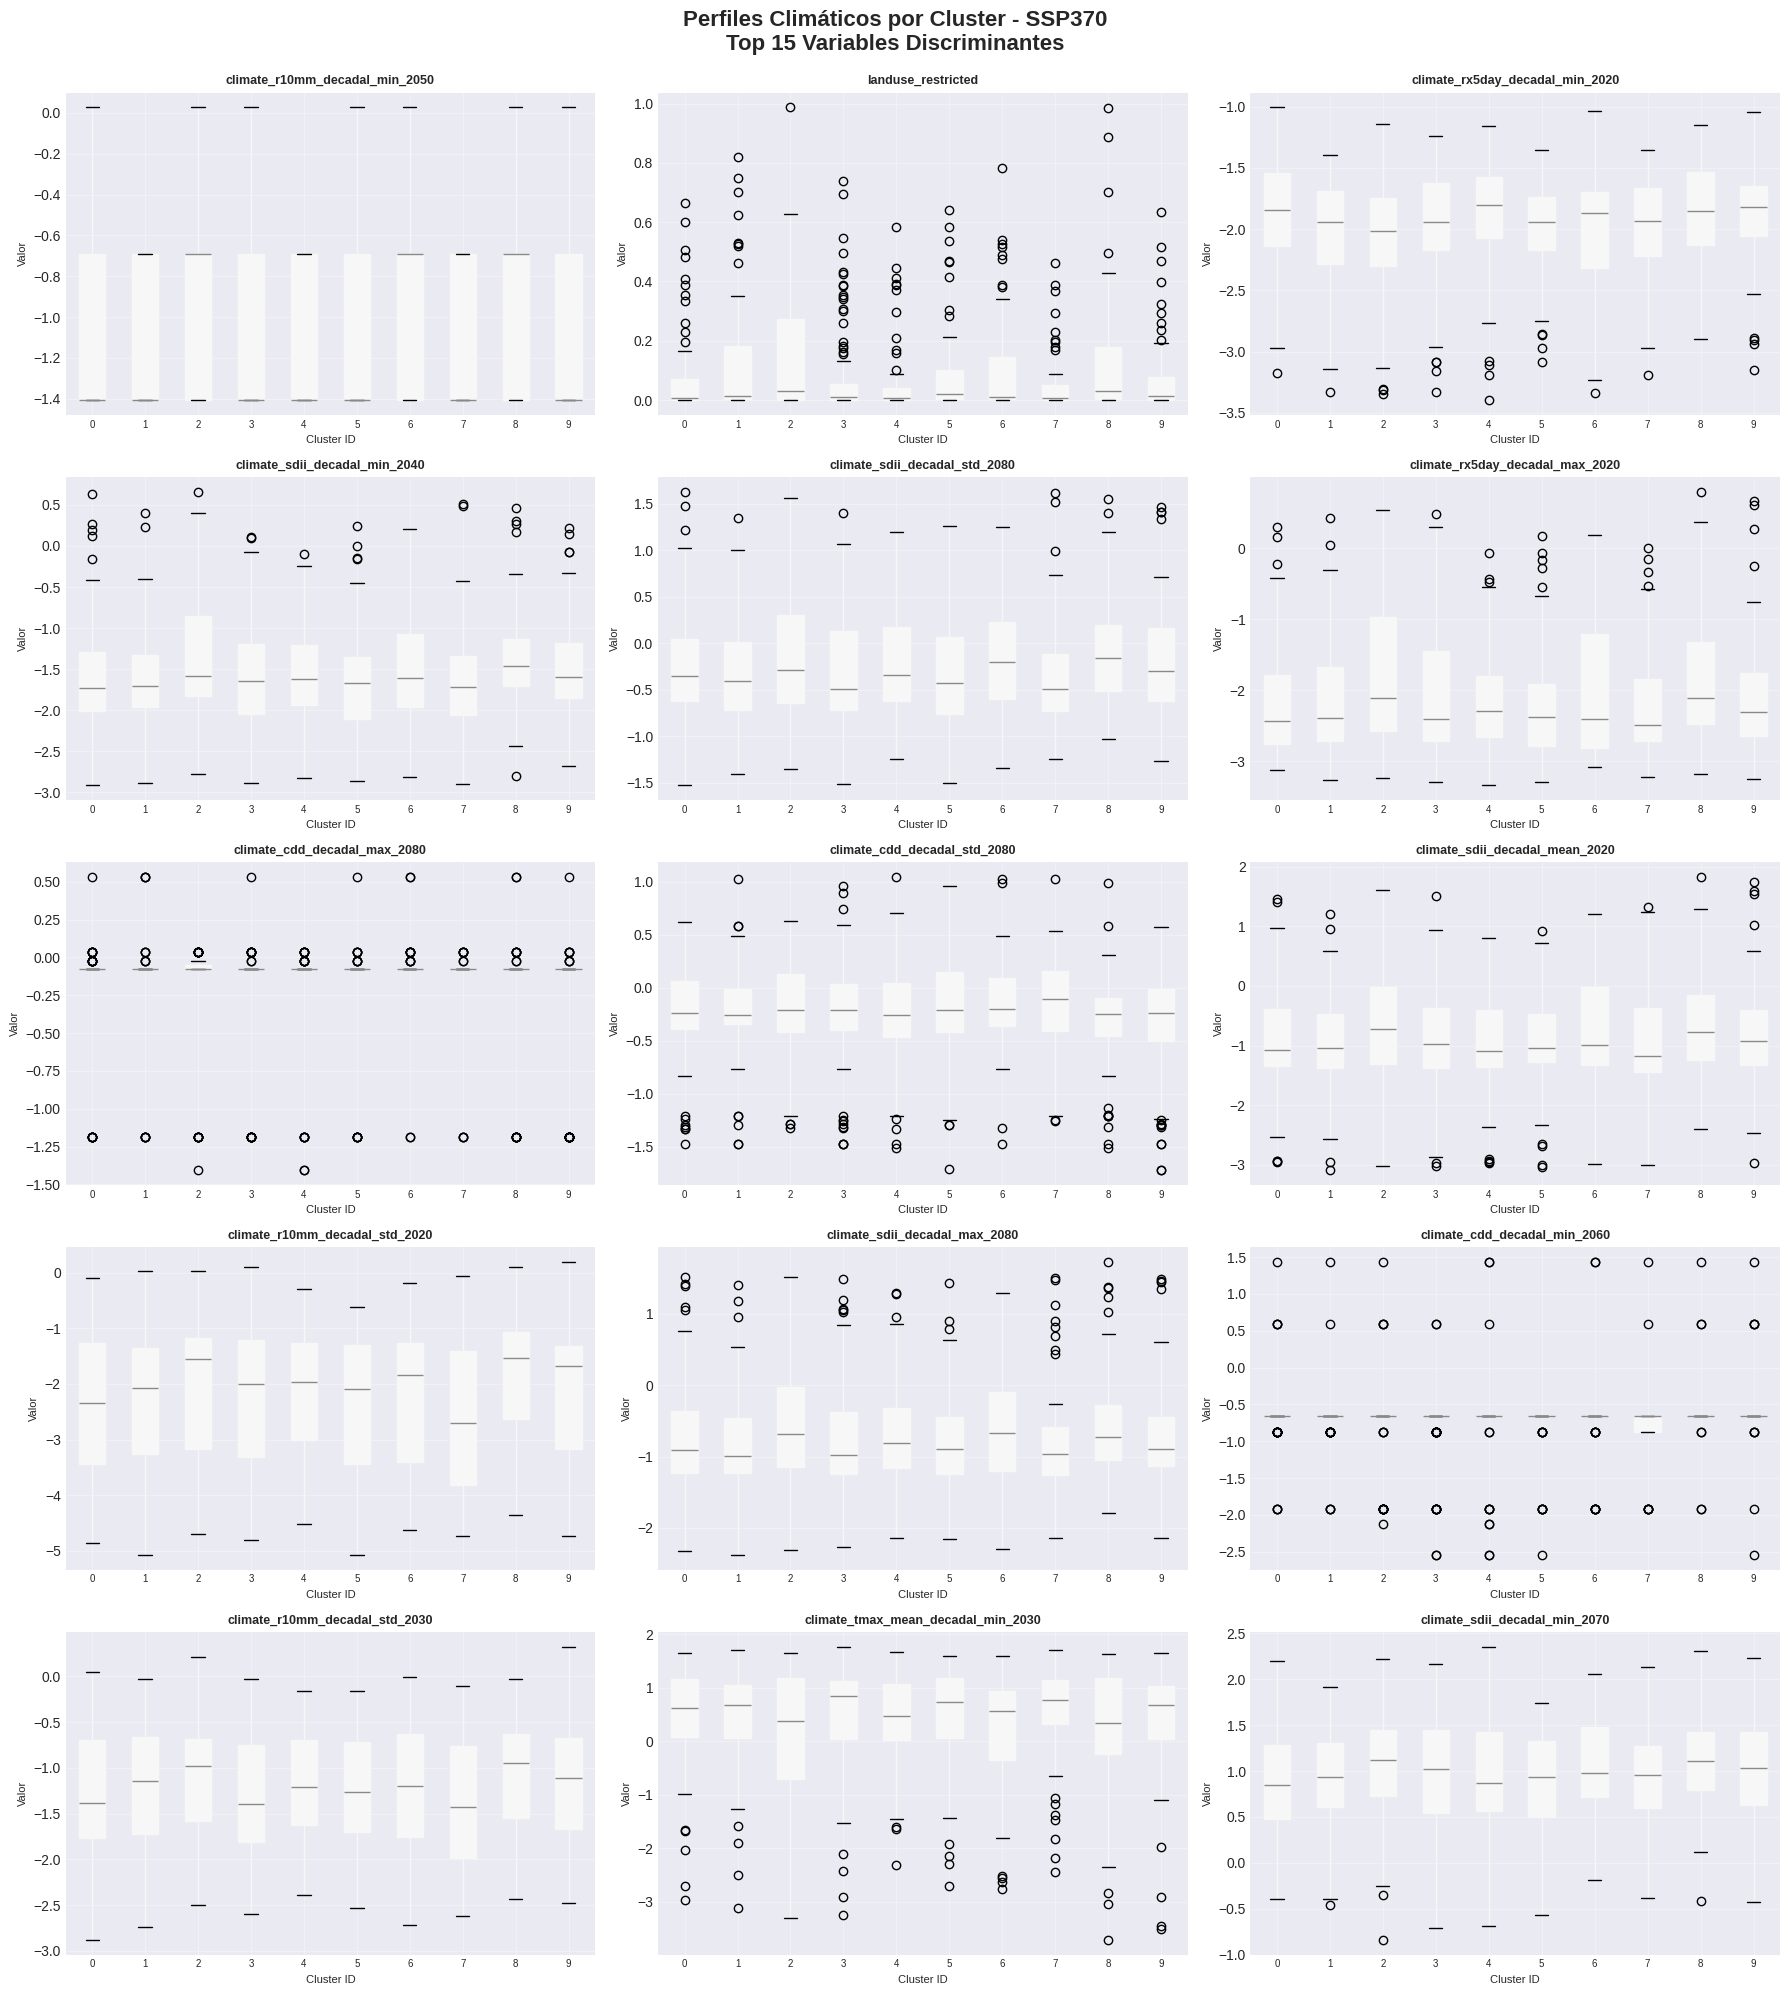

In [7]:
# Box plots de variables clave por cluster
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for idx, var_name in enumerate(top_vars):
    ax = axes[idx]
    
    # Box plot
    df_analysis.boxplot(
        column=var_name,
        by='cluster',
        ax=ax,
        patch_artist=True
    )
    
    ax.set_title(f'{var_name}', fontsize=9, fontweight='bold')
    ax.set_xlabel('Cluster ID', fontsize=8)
    ax.set_ylabel('Valor', fontsize=8)
    ax.grid(alpha=0.3)
    plt.sca(ax)
    plt.xticks(rotation=0, fontsize=7)

# Eliminar subplots vacíos
for idx in range(len(top_vars), len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle(f'Perfiles Climáticos por Cluster - {scenario_example.upper()}\nTop 15 Variables Discriminantes', 
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()

fig_path = PLOTS_DIR / f'boxplots_variables_{scenario_example}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Box plots guardados en: {fig_path}")

plt.show()

## Paso 7: Radar Plots para Comparación de Clusters

Visualizar perfiles multivariables de cada cluster en gráficos de radar.


✅ Radar plots guardados en: /home/aninotna/magister/tesis/justh2_pipeline/plots/cluster_characterization/radar_plots_ssp370.png


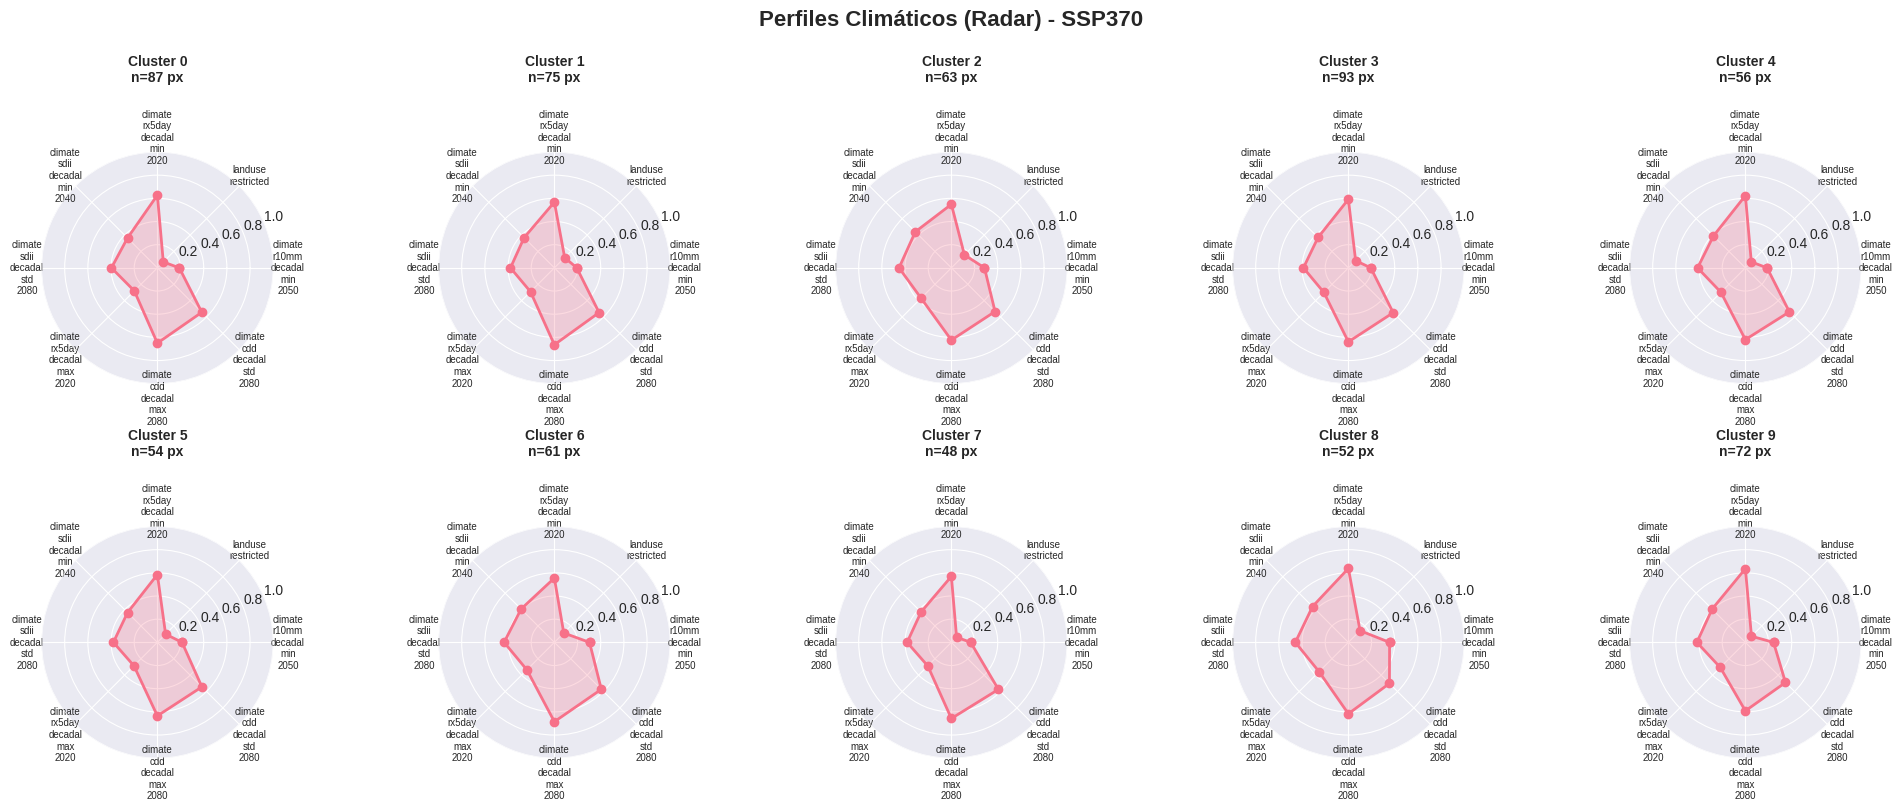

In [8]:
# Radar plots (spider plots) para perfiles de clusters
from math import pi

# Seleccionar 8 variables clave para radar
radar_vars = top_vars[:8]

# Normalizar datos para radar plot (0-1)
X_radar = X_clim[:, [feature_names.index(v) for v in radar_vars]]
X_radar_norm = (X_radar - X_radar.min(axis=0)) / (X_radar.max(axis=0) - X_radar.min(axis=0))

# Calcular medias por cluster
radar_profiles = []
for cluster_id in range(k):
    mask_cluster = (labels == cluster_id)
    profile = X_radar_norm[mask_cluster].mean(axis=0)
    radar_profiles.append(profile)

# Crear subplots para cada cluster
ncols = 5
nrows = (k + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4*nrows), subplot_kw=dict(projection='polar'))
axes = axes.flatten()

angles = [n / float(len(radar_vars)) * 2 * pi for n in range(len(radar_vars))]
angles += angles[:1]

for cluster_id in range(k):
    ax = axes[cluster_id]
    
    values = radar_profiles[cluster_id].tolist()
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([v.replace('_', '\n') for v in radar_vars], fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_title(f'Cluster {cluster_id}\nn={int(cluster_stats.loc[cluster_id, "size"])} px', 
                 fontsize=10, fontweight='bold', pad=20)
    ax.grid(True)

# Eliminar subplots vacíos
for idx in range(k, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle(f'Perfiles Climáticos (Radar) - {scenario_example.upper()}', 
             fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()

fig_path = PLOTS_DIR / f'radar_plots_{scenario_example}.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Radar plots guardados en: {fig_path}")

plt.show()

## Paso 8: Proponer Nombres Descriptivos para Clusters

Basado en los perfiles climáticos, proponer nombres interpretativos.

In [13]:
# Caracterización automática basada en percentiles
print("="*80)
print("PROPUESTA DE NOMBRES DESCRIPTIVOS PARA CLUSTERS")
print("="*80)

cluster_names = {}

# Calcular estadísticas globales para normalización robusta
global_means = X_clim.mean(axis=0)
global_stds = X_clim.std(axis=0)

for cluster_id in range(k):
    mask_cluster = (labels == cluster_id)
    X_cluster = X_clim[mask_cluster]
    
    characteristics = []
    
    # Resiliencia
    mean_resilience = resilience_by_scenario[scenario_example]['resilience'][mask_cluster].mean()
    
    if mean_resilience > 0.65:
        resilience_label = "Alta resiliencia"
    elif mean_resilience > 0.55:
        resilience_label = "Resiliencia moderada-alta"
    elif mean_resilience > 0.45:
        resilience_label = "Resiliencia moderada"
    else:
        resilience_label = "Baja resiliencia"
    
    characteristics.append(resilience_label)
    
    # Calcular desviaciones estandarizadas (z-scores)
    cluster_means = X_cluster.mean(axis=0)
    z_scores = (cluster_means - global_means) / (global_stds + 1e-10)
    
    # Identificar variables más distintivas (mayor z-score absoluto)
    top_distinctive_idx = np.argsort(np.abs(z_scores))[-5:][::-1]
    
    # Analizar patrones basados en top variables del ANOVA
    top_anova_vars = anova_results.head(10)['variable'].tolist()
    
    # Buscar patrones en variables clave
    for var in top_anova_vars:
        if var in feature_names:
            var_idx = feature_names.index(var)
            z = z_scores[var_idx]
            
            if abs(z) > 1.5:  # Desviación significativa
                if 'tmax' in var and z > 0:
                    characteristics.append("Más cálido")
                    break
                elif 'tmax' in var and z < 0:
                    characteristics.append("Más frío")
                    break
                elif 'pr' in var or 'prcptot' in var:
                    if z > 0:
                        characteristics.append("Mayor precipitación")
                        break
                    else:
                        characteristics.append("Menor precipitación")
                        break
    
    cluster_names[cluster_id] = f"Cluster {cluster_id}: {' - '.join(characteristics)}"
    
    print(f"\n{cluster_names[cluster_id]}")
    print(f"   Tamaño: {mask_cluster.sum()} píxeles ({100*mask_cluster.sum()/len(labels):.1f}%)")
    print(f"   Resiliencia: {mean_resilience:.3f}")
    print(f"   Variables más distintivas (z-score):")
    
    for idx in top_distinctive_idx:
        var_name = feature_names[idx]
        z = z_scores[idx]
        cluster_val = cluster_means[idx]
        global_val = global_means[idx]
        
        # Mostrar diferencia de forma más robusta
        if global_val != 0:
            diff_pct = ((cluster_val - global_val) / abs(global_val)) * 100
            print(f"      - {var_name}: z={z:+.2f} ({diff_pct:+.1f}%)")
        else:
            print(f"      - {var_name}: z={z:+.2f} (valor={cluster_val:.3f})")

# Guardar nombres
cluster_names_df = pd.DataFrame([
    {'cluster_id': cid, 'name': name} 
    for cid, name in cluster_names.items()
])

cluster_names_df.to_csv(REPORTS_DIR / f'cluster_names_{scenario_example}.csv', index=False)
print(f"\n✅ Nombres de clusters guardados")
print("="*80)

PROPUESTA DE NOMBRES DESCRIPTIVOS PARA CLUSTERS

Cluster 0: Resiliencia moderada-alta
   Tamaño: 87 píxeles (13.2%)
   Resiliencia: 0.601
   Variables más distintivas (z-score):
      - climate_rx5day_decadal_min_2020: z=+0.17 (+3.9%)
      - landuse_restricted: z=-0.16 (-28.0%)
      - climate_r10mm_decadal_min_2050: z=-0.15 (-5.3%)
      - climate_rx1day_decadal_max_2030: z=-0.14 (-17.9%)
      - climate_rx5day_decadal_max_2020: z=-0.13 (-5.6%)

Cluster 1: Resiliencia moderada-alta
   Tamaño: 75 píxeles (11.3%)
   Resiliencia: 0.556
   Variables más distintivas (z-score):
      - topo_slope: z=+0.21 (+223488346721719840.0%)
      - climate_sdii_decadal_min_2090: z=-0.20 (-502.6%)
      - calliope_cap_electrolyzer_mw: z=+0.17 (+66.2%)
      - climate_sdii_decadal_max_2080: z=-0.17 (-19.2%)
      - climate_sdii_decadal_mean_2040: z=-0.17 (-5.7%)

Cluster 2: Resiliencia moderada-alta
   Tamaño: 63 píxeles (9.5%)
   Resiliencia: 0.566
   Variables más distintivas (z-score):
      - landu

## Paso 9: Análisis de Cambios entre Escenarios SSP

Comparar cómo cambian los clusters entre SSP245, SSP370 y SSP585.

CAMBIOS EN DISTRIBUCIÓN DE CLUSTERS ENTRE ESCENARIOS

✅ Distribución guardada en: /home/aninotna/magister/tesis/justh2_pipeline/plots/cluster_characterization/cluster_distribution_scenarios.png

✅ Distribución guardada en: /home/aninotna/magister/tesis/justh2_pipeline/plots/cluster_characterization/cluster_distribution_scenarios.png


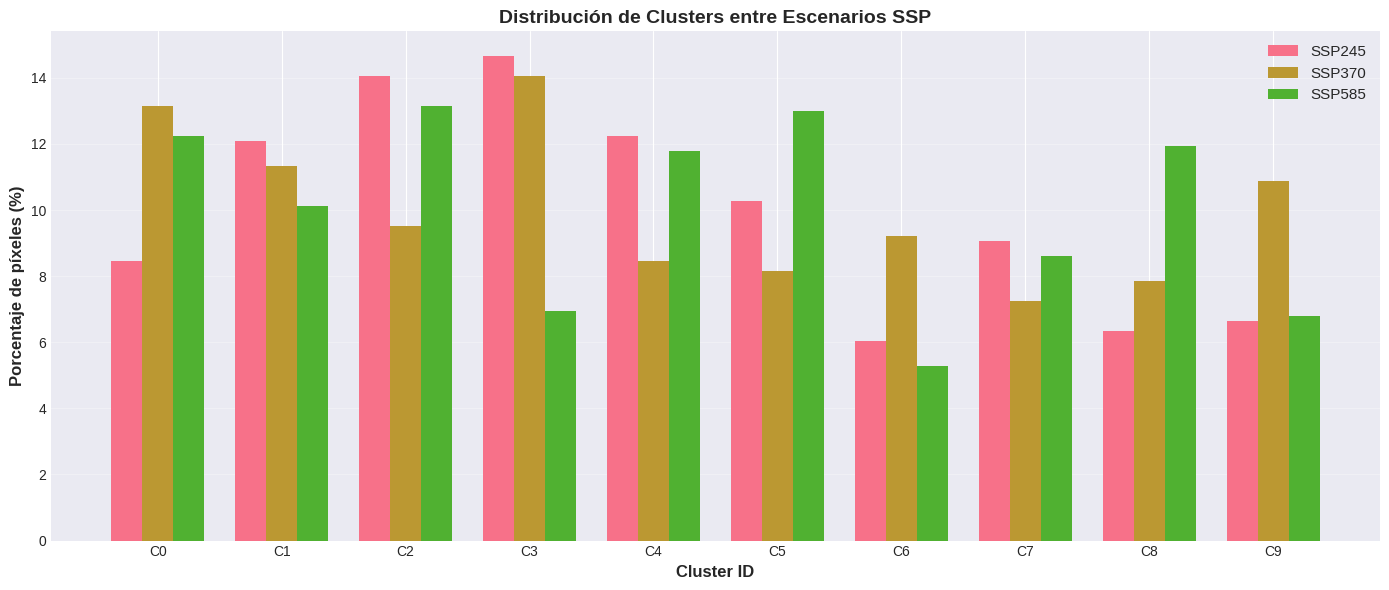

✅ Tabla guardada


In [14]:
# Comparación de distribución de clusters entre escenarios
print("="*80)
print("CAMBIOS EN DISTRIBUCIÓN DE CLUSTERS ENTRE ESCENARIOS")
print("="*80)

# Crear DataFrame para comparación
cluster_distribution = []

for scenario in SCENARIOS:
    labels_scenario = resilience_by_scenario[scenario]['labels']
    k_scenario = clustering_results[scenario]['k']
    
    for cluster_id in range(k_scenario):
        n_pixels = (labels_scenario == cluster_id).sum()
        pct = 100 * n_pixels / len(labels_scenario)
        
        cluster_distribution.append({
            'scenario': scenario,
            'cluster_id': cluster_id,
            'n_pixels': n_pixels,
            'percentage': pct
        })

df_distribution = pd.DataFrame(cluster_distribution)

# Visualización
fig, ax = plt.subplots(figsize=(14, 6))

# Grouped bar plot
scenarios_unique = df_distribution['scenario'].unique()
x = np.arange(k)  # Asumiendo mismo K para todos (ajustar si difiere)
width = 0.25

for idx, scenario in enumerate(scenarios_unique):
    df_scenario = df_distribution[df_distribution['scenario'] == scenario]
    values = [df_scenario[df_scenario['cluster_id'] == cid]['percentage'].values[0] 
              if len(df_scenario[df_scenario['cluster_id'] == cid]) > 0 else 0
              for cid in range(k)]
    
    ax.bar(x + idx*width, values, width, label=scenario.upper())

ax.set_xlabel('Cluster ID', fontsize=12, fontweight='bold')
ax.set_ylabel('Porcentaje de píxeles (%)', fontsize=12, fontweight='bold')
ax.set_title('Distribución de Clusters entre Escenarios SSP', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels([f'C{i}' for i in range(k)])
ax.legend(fontsize=11)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()

fig_path = PLOTS_DIR / 'cluster_distribution_scenarios.png'
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f"\n✅ Distribución guardada en: {fig_path}")

plt.show()

# Guardar tabla
df_distribution.to_csv(REPORTS_DIR / 'cluster_distribution_scenarios.csv', index=False)
print("✅ Tabla guardada")

## Paso 10: Resumen Final y Recomendaciones

Generar reporte ejecutivo con hallazgos clave.

In [ ]:
print("\n" + "="*80)
print("RESUMEN EJECUTIVO: CARACTERIZACIÓN DE CLUSTERS")
print("="*80)

print("\nHALLAZGOS PRINCIPALES:")
print("-" * 70)

print(f"\n1. NÚMERO DE CLUSTERS IDENTIFICADOS:")
for scenario in SCENARIOS:
    k_s = clustering_results[scenario]['k']
    sil_s = clustering_results[scenario]['silhouette']
    print(f"   {scenario.upper()}: {k_s} clusters (Silhouette={sil_s:.4f})")

print(f"\n2. VARIABLES MÁS DISCRIMINANTES:")
print(f"   Top 5:")
for idx, row in anova_results.head(5).iterrows():
    print(f"   - {row['variable']}: F={row['f_statistic']:.2f}, p<{row['p_value']:.2e}")

print(f"\n3. DISTRIBUCIÓN DE RESILIENCIA:")
for scenario in SCENARIOS:
    res = resilience_by_scenario[scenario]['resilience']
    print(f"   {scenario.upper()}: Media={res.mean():.3f}, Std={res.std():.3f}")

print(f"\n4. CLUSTERS CON MAYOR RESILIENCIA ({scenario_example.upper()}):")
top3_resilient = cluster_stats.nlargest(3, 'resilience_mean')
for cluster_id, row in top3_resilient.iterrows():
    cluster_name = cluster_names.get(cluster_id, f"Cluster {cluster_id}")
    print(f"   {cluster_name}")
    print(f"      Resiliencia: {row['resilience_mean']:.3f} | Área: {row['size_pct']:.1f}%")

print(f"\n5. CLUSTERS CON MENOR RESILIENCIA ({scenario_example.upper()}):")
bottom3_resilient = cluster_stats.nsmallest(3, 'resilience_mean')
for cluster_id, row in bottom3_resilient.iterrows():
    cluster_name = cluster_names.get(cluster_id, f"Cluster {cluster_id}")
    print(f"   {cluster_name}")
    print(f"      Resiliencia: {row['resilience_mean']:.3f} | Área: {row['size_pct']:.1f}%")

print("\nRECOMENDACIONES:")
print("-" * 70)
print("1. Priorizar intervenciones en clusters de baja resiliencia")
print("2. Desarrollar estrategias diferenciadas por zona climática")
print("3. Monitorear cambios en distribución de clusters entre escenarios")
print("4. Validar interpretaciones con expertos locales del Valle de Aconcagua")
print("5. Usar nombres descriptivos para comunicar resultados a stakeholders")

print("\nARCHIVOS GENERADOS:")
print("-" * 70)
print(f"   Visualizaciones:")
print(f"      - {PLOTS_DIR / f'boxplots_variables_{scenario_example}.png'}")
print(f"      - {PLOTS_DIR / f'radar_plots_{scenario_example}.png'}")
print(f"      - {PLOTS_DIR / 'cluster_distribution_scenarios.png'}")
print(f"   Reportes CSV:")
print(f"      - {REPORTS_DIR / f'cluster_stats_{scenario_example}.csv'}")
print(f"      - {REPORTS_DIR / f'discriminant_variables_{scenario_example}.csv'}")
print(f"      - {REPORTS_DIR / f'cluster_names_{scenario_example}.csv'}")
print(f"      - {REPORTS_DIR / 'cluster_distribution_scenarios.csv'}")

print("\n" + "="*80)
print("CARACTERIZACIÓN COMPLETA")
print("="*80)

RESUMEN EJECUTIVO: CARACTERIZACIÓN DE CLUSTERS

📊 HALLAZGOS PRINCIPALES:
----------------------------------------------------------------------

1. NÚMERO DE CLUSTERS IDENTIFICADOS:
   SSP245: 10 clusters (Silhouette=0.2194)
   SSP370: 10 clusters (Silhouette=0.2207)
   SSP585: 10 clusters (Silhouette=0.2245)

2. VARIABLES MÁS DISCRIMINANTES:
   Top 5:
   - climate_r10mm_decadal_min_2050: F=3.16, p<9.51e-04
   - landuse_restricted: F=2.26, p<1.70e-02
   - climate_rx5day_decadal_min_2020: F=2.06, p<3.10e-02
   - climate_sdii_decadal_min_2040: F=1.45, p<1.61e-01
   - climate_sdii_decadal_std_2080: F=1.43, p<1.71e-01

3. DISTRIBUCIÓN DE RESILIENCIA:
   SSP245: Media=0.548, Std=0.171
   SSP370: Media=0.557, Std=0.171
   SSP585: Media=0.527, Std=0.183

4. CLUSTERS CON MAYOR RESILIENCIA (SSP370):
   Cluster 8: Resiliencia=0.667 (7.9% del área)
   Cluster 7: Resiliencia=0.610 (7.3% del área)
   Cluster 0: Resiliencia=0.601 (13.2% del área)

5. CLUSTERS CON MENOR RESILIENCIA (SSP370):
   Clust